In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load data file
df = pd.read_csv("../data/Online Retail.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
#clean the data(critical)

# remove rows with missing  customerid
df = df.dropna(subset=["CustomerID"])

# Remove negative or zero  values( return/ invalid)
df = df[df["Quantity"]>0]
df = df[df["UnitPrice"]>0]

# convert datatype
df["InvoiceDate"]= pd.to_datetime(df["InvoiceDate"])

# remove duplicate
df = df.drop_duplicates()

In [6]:
# create revanue column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [7]:
# create month column (needed for cohort)
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")

In [8]:
# customer lifetime value (clv)
clv = df.groupby("CustomerID")["Revenue"].sum().reset_index()
clv = clv.sort_values(by="Revenue", ascending=False)

clv.head()

,CustomerID,Revenue
1689,14646.0,280206.02
4201,18102.0,259657.30
3728,17450.0,194390.79
3008,16446.0,168472.50
1879,14911.0,143711.17


In [9]:
# customer segment

def segment(x):
    if x > 10000:
        return"High Value"
    elif x > 5000:
        return"Low Value"
    else:
        return"Low Value"
    
clv["Segment"] = clv["Revenue"].apply(segment)
clv.head()

,CustomerID,Revenue,Segment
1689,14646.0,280206.02,High Value
4201,18102.0,259657.30,High Value
3728,17450.0,194390.79,High Value
3008,16446.0,168472.50,High Value
1879,14911.0,143711.17,High Value


In [10]:
#  cohort  (first purchase)
cohort=df.groupby("CustomerID")["Revenue"].min().reset_index()
cohort.columns = ["CustomerID", "cohortMonth"]

In [11]:
# merge back
df = df.merge(cohort, on="CustomerID")

In [12]:
cohort = df.groupby("CustomerID")["InvoiceMonth"].min().reset_index()
cohort.columns = ["CustomerID", "CohortMonth"]

In [13]:
df = df.merge(cohort, on="CustomerID")

In [14]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'InvoiceMonth',
       'cohortMonth', 'CohortMonth'],
      dtype='str')


In [15]:
# cohort index
df["CohortIndex"] = (df["InvoiceMonth"] - df["CohortMonth"]).apply(lambda x: x.n)

In [16]:
#Create retention table
cohort_data = df.groupby(["CohortMonth", "CohortIndex"])["CustomerID"].nunique().reset_index()

cohort_pivot = cohort_data.pivot(index="CohortMonth", columns="CohortIndex", values="CustomerID")

cohort_pivot.head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN


In [17]:
#Convert to retention rate
cohort_size = cohort_pivot.iloc[:, 0]

retention = cohort_pivot.divide(cohort_size, axis=0)

retention.head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN


#### matlpotlib


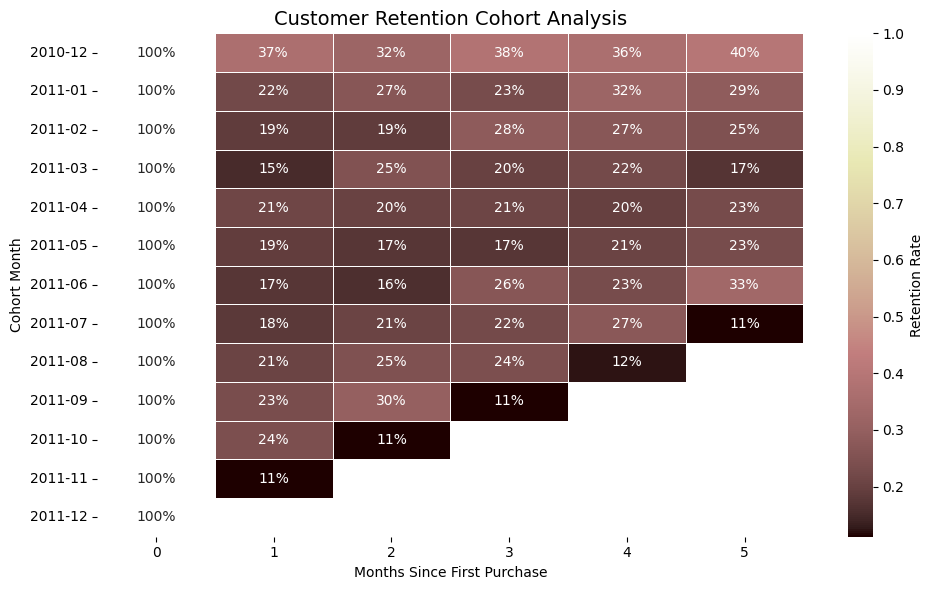

In [21]:
# limit to first 6 months
retention_subset = retention.iloc[:, :6]

plt.figure(figsize=(10,6))

sns.heatmap(
    retention_subset,
    annot=True,
    fmt=".0%",
    cmap="pink",
    linewidths=0.5,
    cbar_kws={'label': 'Retention Rate'}
)

plt.title("Customer Retention Cohort Analysis", fontsize=14)
plt.ylabel("Cohort Month")
plt.xlabel("Months Since First Purchase")

plt.tight_layout()
plt.show()

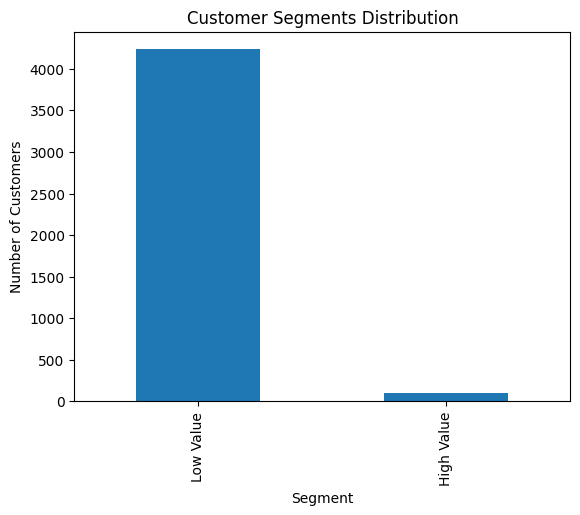

In [24]:
clv["Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

In [25]:
clv["Segment"] = pd.qcut( 
    clv["Revenue"], 
    q=3, 
    labels=["Low Value", "Medium Value", "High Value"] 
)

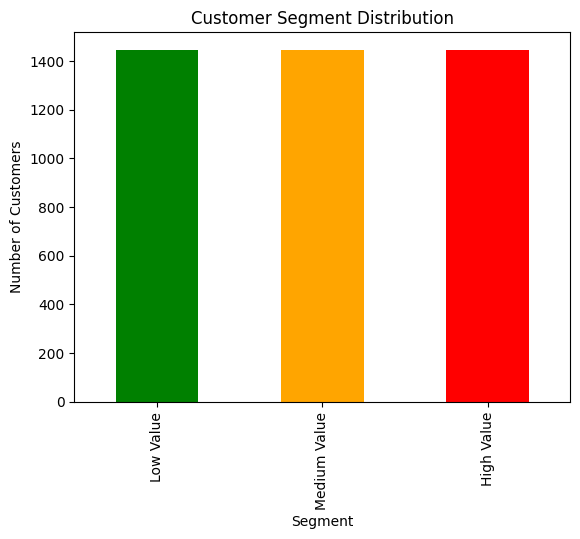

In [26]:
clv["Segment"].value_counts().plot(kind="bar", color=["green","orange","red"]) # bar plot with colors

plt.title("Customer Segment Distribution") # title
plt.xlabel("Segment") # x-axis label
plt.ylabel("Number of Customers") # y-axis label

plt.show()

In [27]:
df = pd.read_csv("../data/Online Retail.csv")

# Remove null customers
df = df.dropna(subset=["CustomerID"])

# Remove returns (optional but better)
df = df[df["Quantity"] > 0]

# Create revenue
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Keep only required columns
df = df[[
    "InvoiceNo",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "UnitPrice",
    "CustomerID",
    "Country",
    "Revenue"
]]

# Save clean file
df.to_csv("clean_retail_final.csv", index=False)